In [138]:
import numpy as np
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin1')

In [139]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [140]:
df.shape

(5572, 5)

In [141]:
df.drop(columns = ['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [142]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [143]:
df.rename(columns={'v1':'target','v2':'text'},inplace = True)

In [144]:
df.sample(4)

,target,text
5171,ham,Oh k. . I will come tomorrow
2064,ham,Pass dis to all ur contacts n see wat u get! R...
4522,ham,Actually I decided I was too hungry so I haven...
2098,ham,"No dice, art class 6 thru 9 :( thanks though. ..."


In [145]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [146]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [147]:
df.isnull().sum()

,0
target,0
text,0


In [148]:
df.duplicated().sum()

np.int64(403)

In [149]:
df.drop_duplicates(keep='first',inplace = True)

In [150]:
df.duplicated().sum()

np.int64(0)

In [151]:
df.shape

(5169, 2)

In [152]:
df['target'].value_counts()

,count
target,
0,4516
1,653


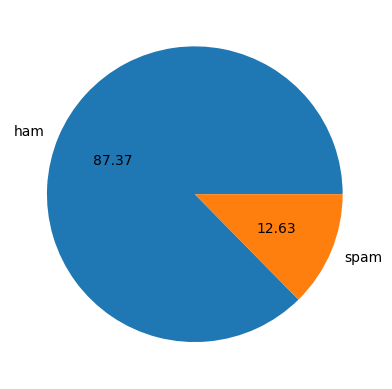

In [153]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [154]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [155]:
df['num_characters'] = df['text'].apply(lambda x:len(x))

In [156]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [157]:
df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [158]:
df['num_sentences'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [159]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [160]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [161]:
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [162]:
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

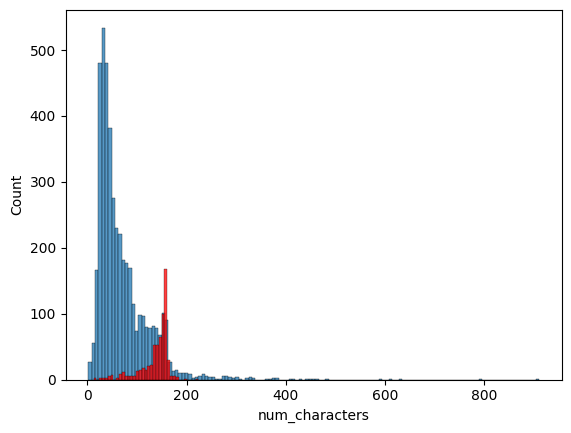

In [163]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

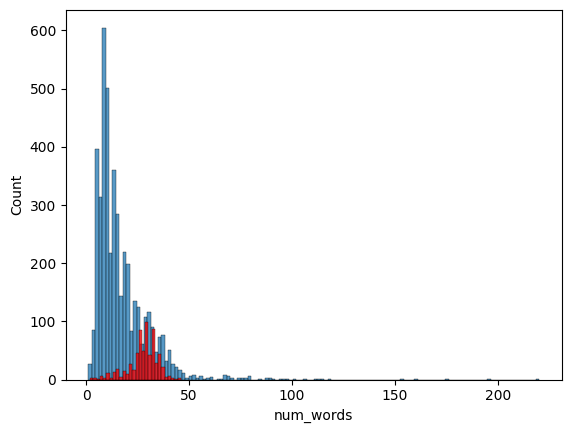

In [164]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

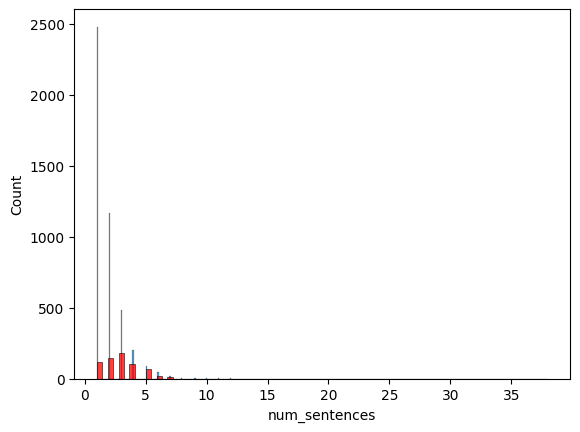

In [165]:
sns.histplot(df[df['target']==0]['num_sentences'])
sns.histplot(df[df['target']==1]['num_sentences'],color='red')

In [166]:
df[['num_characters','num_words','num_sentences', 'target']].corr()

,num_characters,num_words,num_sentences,target
num_characters,1.000000,0.965760,0.624139,0.384717
num_words,0.965760,1.000000,0.679971,0.262912
num_sentences,0.624139,0.679971,1.000000,0.263939
target,0.384717,0.262912,0.263939,1.000000


<Axes: >

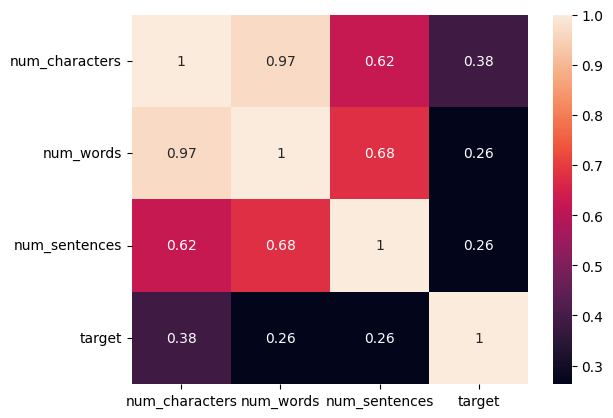

In [167]:
sns.heatmap(df[['num_characters','num_words','num_sentences', 'target']].corr(), annot = True)

In [168]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords') # Ensure stopwords are downloaded
stop_words = stopwords.words('english')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
import string
def transfrorm_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text) # Pass 'text' to word_tokenize
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text=y[:]
  y.clear()
  for i in text :
    if i not in stop_words and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))


  return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [169]:
df['transformed_text'] = df['text'].apply(transfrorm_text)

In [170]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [171]:
from wordcloud import WordCloud
wc = WordCloud(width = 500 , height = 500 , min_font_size = 10 , background_color = 'white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))


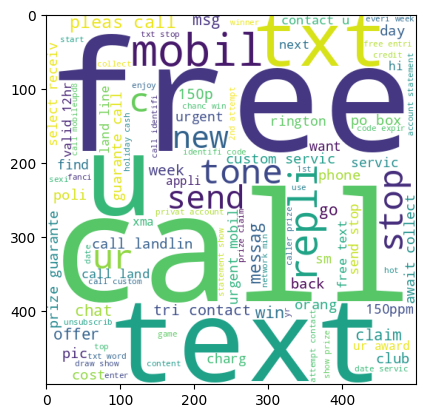

In [172]:
plt.imshow(spam_wc
           )

In [173]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

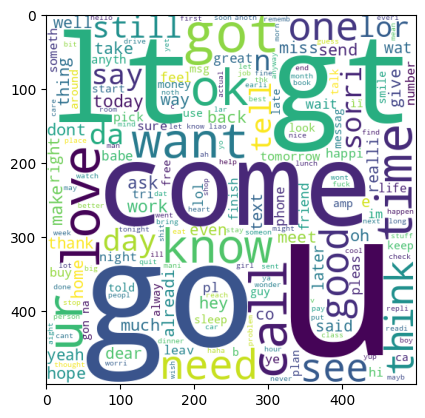

In [174]:
plt.imshow(ham_wc)

In [175]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


In [176]:
len(spam_corpus)

9939

In [177]:
from collections import Counter

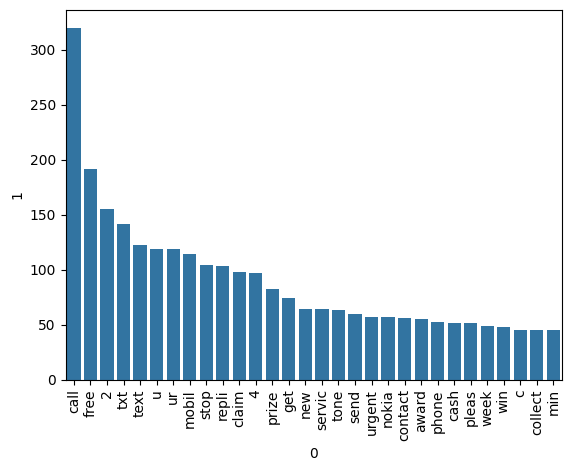

In [178]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1
                                                                                                                         ])
plt.xticks(rotation='vertical')
plt.show()

In [179]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)


In [180]:
len(ham_corpus)

35404

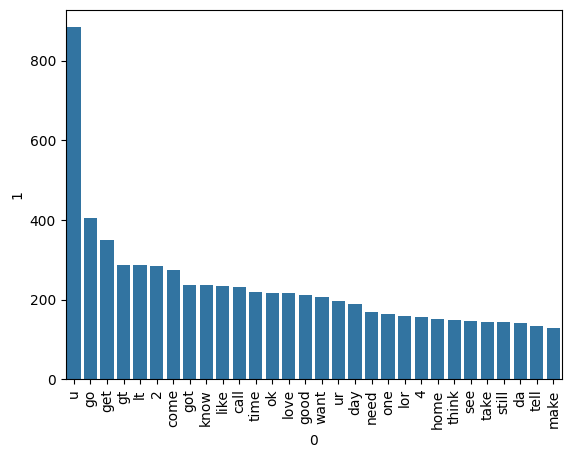

In [181]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1
                                                                                                                         ])
plt.xticks(rotation='vertical')
plt.show()

In [212]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf= TfidfVectorizer(max_features=3000)
cv = CountVectorizer()
X = cv.fit_transform(df['transformed_text']).toarray()
Xt = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values



In [213]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(Xt,y,test_size=0.2,random_state=2)

In [214]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB, BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [215]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix,precision_score

In [216]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [217]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [218]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [219]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier


In [220]:
svc = SVC(kernel = 'sigmoid', gamma = 1.0, probability=True)
kNN = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver ='liblinear',penalty = 'l1')
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
adc = AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50 , random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [221]:
clfs = {
    'SVC':svc,
    'KNN':kNN,
    'MNB':mnb,
    'DTC':dtc,
    'LRC':lrc,
    'RFC':rfc,
    'ADC':adc,
    'BC':bc,
    'ETC':etc,
    'GBC':gbc,
    'XGB':xgb
}

In [222]:
def train_models(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision= precision_score(y_test,y_pred)

  return accuracy,precision


In [223]:
accuracy =[]
precision=[]

for name,clf in clfs.items():
  current_accuracy,current_precision=train_models(clf,X_train,y_train,X_test,y_test)
  print(f"For{name}")
  print("accuraacy : ",current_accuracy)
  print("precision : ", current_precision)

  accuracy.append(current_accuracy)
  precision.append(current_precision)


ForSVC
accuraacy :  0.9758220502901354
precision :  0.9747899159663865
ForKNN
accuraacy :  0.9052224371373307
precision :  1.0
ForMNB
accuraacy :  0.9709864603481625
precision :  1.0
ForDTC
accuraacy :  0.9323017408123792
precision :  0.8333333333333334
ForLRC
accuraacy :  0.9555125725338491
precision :  0.96
ForRFC
accuraacy :  0.9738878143133463
precision :  0.9826086956521739
ForADC
accuraacy :  0.9216634429400387
precision :  0.8202247191011236
ForBC
accuraacy :  0.9584139264990329
precision :  0.8682170542635659
ForETC
accuraacy :  0.9748549323017408
precision :  0.9745762711864406
ForGBC
accuraacy :  0.9506769825918762
precision :  0.9306930693069307
ForXGB
accuraacy :  0.9700193423597679
precision :  0.9572649572649573


In [224]:
performance_df = pd.DataFrame({'Algorithms':clfs.keys(),'Accuracy':accuracy,'Precision':precision})

In [225]:
performance_df

,Algorithms,Accuracy,Precision
0,SVC,0.975822,0.974790
1,KNN,0.905222,1.000000
2,MNB,0.970986,1.000000
3,DTC,0.932302,0.833333
4,LRC,0.955513,0.960000
5,RFC,0.973888,0.982609
6,ADC,0.921663,0.820225
7,BC,0.958414,0.868217
8,ETC,0.974855,0.974576
9,GBC,0.950677,0.930693


In [226]:
voting = VotingClassifier(estimators=[('svm',svc),('mnb',mnb),('etc',etc)],voting='soft')

In [227]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('mnb', MultinomialNB()),
                             ('etc',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [228]:
y_predict = voting.predict(X_test)

In [229]:
print(accuracy_score(y_test,y_predict))
print(precision_score(y_test,y_predict))

0.9806576402321083
0.9836065573770492


In [231]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))